In [1417]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from scipy import optimize
from sklearn.linear_model import LinearRegression
from set_rcParams import set_rcParams
set_rcParams()


In [1418]:
# the final temperature from a uniformly distributed speed
m = 1 * u.kg
v_max = 0.5 * u.m / u.s
T_f = (m * v_max**2 / (9 * c.k_B)).to(u.K)


def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * c.k_B.value * T))**(3/2) * np.exp(- m * v**2 / (2 * c.k_B.value * T))


def f_M_v(v, T, m):
  return (m / (2 * np.pi * c.k_B.value * T))**(1/2) * np.exp(- m * v**2 / (2 * c.k_B.value * T))


def uniform_dist(v, v_max):
  # zeros = np.zeros_like(v)[np.where(v < v_max)[0]]
  initial = np.ones_like(v)
  initial[np.where(v > v_max)[0]] = 0
  return 1 / v_max * initial

In [1419]:
speed_range = np.linspace(0, 1, 1000) * u.m/ u.s
n = 1
sigma = 1
nu_c = n
nu = nu_c / 2
T_x = 373
T_yz = 273

T_f = (2 * 273 + 373) / 3
m = 6.6e-26
v_range = np.linspace(-1e3, 1e3, 1000)

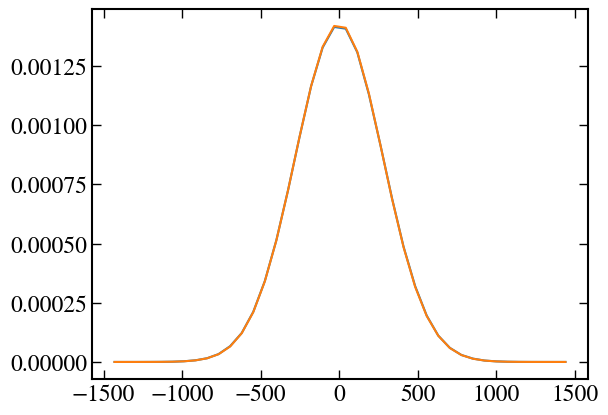

In [1420]:
i = 1
bins = 30
# bgk_x = lambda v, nu, t: f_M_v(v, T_f, m) + np.exp(-nu * t) * (f_M_v(v_range, T_x, m) - f_M_v(v, T_f, m))
# bgk_yz = lambda v, nu, t: f_M_v(v, T_f, m) + np.exp(-nu * t) * (f_M_v(v_range, T_yz, m) - f_M_v(v, T_f, m))

data = pd.read_csv("testing_csv_distribution_0001.csv")
v_x_centers = ((data["v_x_lower"] + data["v_x_upper"]) / 2).to_numpy()
v_x_counts = data["v_x"]
total = np.trapezoid(v_x_counts, v_x_centers)

plt.figure()
plt.plot(v_x_centers, v_x_counts / total)
plt.plot(v_x_centers, f_M_v(v_x_centers, T_x, m))
plt.show()


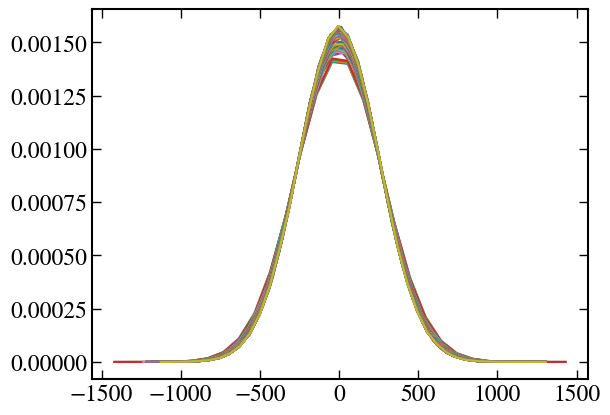

In [1421]:
start = 10
end = 1000
errors = []
plt.figure()
for i in range(start, end, 10):
  data = pd.read_csv(f"testing_csv_distribution_{i:04d}.csv")
  v_x_centers = ((data["v_x_lower"] + data["v_x_upper"]) / 2).to_numpy()
  v_x_counts = data["v_x"]
  total = np.trapezoid(v_x_counts, v_x_centers)
  v_x_pdf = v_x_counts/ total
#   hist, edges = np.histogram(data["v_x"], bins=50, density=True)
#   centers = (edges[1:] + edges[:-1]) / 2

  errors.append(np.linalg.norm(v_x_pdf - f_M_v(v_x_centers, T_f, m)))
  plt.plot(v_x_centers, v_x_pdf)
  # print(error)
plt.show()
#   bins=50
#   plt.figure()
#   plt.hist(data['v_x'], bins=bins, density=True)
  # # #
  # plt.plot(v_range, f_M_v(v_range, T_x, m))
  # # plt.plot(v_range, f_M_v(v_range, T_f, m))
  # # plt.plot(centers, hist - f_M_v(centers, T_f, m))
  # # plt.plot(v_range, bgk_x(v_range, nu, 1e-2 * i))
  # plt.show()

  # plt.figure()
  # plt.hist(data['v_y'], bins=bins, density=True)
  # # plt.plot(v_range, f_M_v(v_range, T_yz, m))
  # # plt.plot(v_range, f_M_v(v_range, T_f, m))
  # # plt.plot(v_range, bgk_yz(v_range, nu, 1e-2 * i))
  # plt.show()
  # plt.figure()
  # plt.hist(data['v_z'], bins=bins, density=True)
  # # plt.plot(v_range, f_M_v(v_range, T_yz, m))
  # # plt.plot(v_range, f_M_v(v_range, T_f, m))
  # # plt.plot(v_range, bgk_yz(v_range, nu, 1e-2 * i))
  # plt.show()


[[-0.39484942]]


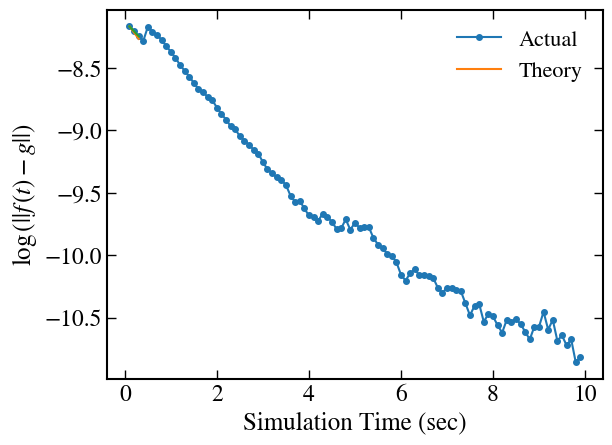

In [ ]:
errors = np.array(errors)
time = (np.arange(start, end, 10) * 1e-2)

start_time = 0
stop_time = .5
mid_point = (start_time + stop_time) / 2
start_idx = np.where(time >= start_time)[0][0]
stop_idx = np.where(time >= stop_time)[0][0]

fitting_time = time[start_idx:stop_idx].reshape((-1, 1))
fitting_data = np.log(errors[start_idx:stop_idx]).reshape((-1, 1))
fit = LinearRegression().fit(fitting_time,fitting_data)
print(fit.coef_)


# errors = np.array(errors)
# start_time = 0
# stop_time = 6
# mid_point = (start_time + stop_time) / 2
# start_idx = np.where(time >= start_time)[0][0]
# stop_idx = np.where(time >= stop_time)[0][0]

# fitting_time = time[start_idx:stop_idx].reshape((-1, 1))
# fitting_data = np.log(errors[start_idx:stop_idx]).reshape((-1, 1))
# fit = LinearRegression().fit(fitting_time,fitting_data)
# print(fit.coef_)


plt.figure()
plt.plot(time, np.log(errors), '-o', markersize=4, label='Actual')
plt.plot(fitting_time, -nu * (fitting_time - time[0]) + np.log(errors[0]), label='Theory')
plt.plot(fitting_time, fit.predict(fitting_time.reshape(-1, 1)))
plt.legend()
plt.ylabel("$\\log\\left(||f\\,(t) - g||\\right)$")
plt.xlabel("Simulation Time (sec)")
plt.show()

In [1423]:
# nx_vals = np.array([1, 2, 5, 10])
# ny_vals = [1, 2, 5, 10]
# vals = []
# plt.figure()
# for i, nx in enumerate(nx_vals):
#   # for j, ny in enumerate(ny_vals):
#   data = pd.read_csv(f"refinement/testing_{nx:d}x{nx:d}_particles_0100.csv")
#   speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
#   hist, edges = np.histogram(speed, bins=50, density=True)
#   centers = (edges[1:] + edges[:-1]) / 2

#   plt.plot(centers,hist,label=f"{nx:d}x{nx:d}")

# data = pd.read_csv(f"testing_out_particles_0100.csv")
# speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
# hist, edges = np.histogram(speed, bins=50, density=True)
# centers = (edges[1:] + edges[:-1]) / 2

# plt.plot(centers,hist,label=f"1x1 Moving Particles")

# bgk = lambda v, nu, t: f_M(v, T_f.value, m.value) + np.exp(-nu * t) * (uniform_dist(v, v_max.value) - f_M(v, T_f.value, m.value))
# plt.plot(speed_range, bgk(speed_range.value, nu / 1000, 1e-2 * 100), '--', label="BGK Approximation")

# plt.legend()
# plt.show()


In [1424]:
# # `data = pd.read_csv("refinement/testing_10x10_particles_0500.csv")

# # speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
# # hist_all, edges = np.histogram(speed, bins=50, density=True)
# # centers_all = (edges[1:] + edges[:-1]) / 2



# for i in range(100, 600, 100):
#   plt.figure()
#   data = pd.read_csv(f"refinement/testing_10x10_particles_{i:04d}.csv")
#   speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
#   hist, edges = np.histogram(speed, bins=50, density=True)
#   centers = (edges[1:] + edges[:-1]) / 2
#   mid_idx = np.where(centers >= 0.25)[0][0]
#   # print(i, hist[mid_idx])
#   vals.append(hist[mid_idx])
#   # plt.plot(centers[mid_idx], hist[mid_idx], 'o')
#   plt.plot(centers,hist,label=f"t = {i * 1e-2:0.2f}")
#   plt.plot(speed_range, bgk(speed_range.value, nu, 1e-2 * i), '--', label="BGK Approximation")
#   plt.legend()
#   plt.show()



# # plt.plot(speed_range, bgk(speed_range.value, nu, 1e-2 * 500), '--', label="BGK Approximation")
# # plt.plot(speed_range, f_M(speed_range.value, T_f.value, m.value), '--', label='Maxwellian')
